# Isolated Model Analysis: XGBOOST_MODEL

This notebook is dedicated entirely to deeply analyzing the xgboost_model regression model (The 'Smart Thermometer'). It generates 7 highly specific diagnostic graphs to prove the model's accuracy, check for biases, and find exactly where it makes mistakes.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('../../data/raw/AE_DATA_with_AvgEGT.csv')
df = df.drop_duplicates().dropna()
if 'AvgEGT' in df.columns:
    df = df[df['AvgEGT'] <= 1000]

# 2. Exclude Features
excluded_cols = [
    "EXHAUST TEMP 1", "EXHAUST TEMP 2", "EXHAUST TEMP 3", 
    "EXHAUST TEMP 4", "EXHAUST TEMP 5", "EXHAUST TEMP 6",
    "FREQ", "AMP", "CPW IN TEMP", "CPW OUT TEMP"
]
drop_cols = [c for c in excluded_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# 3. Split & Scale
X = df.drop(columns=['AvgEGT'])
y = df['AvgEGT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

from xgboost import XGBRegressor

# 4. Initialize Model
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

# 5. Train and Evaluate

model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print("--- Model Results ---")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


--- Model Results ---
R² Score: 0.9136
MAE:      7.8163
RMSE:     10.8307


In [2]:
model_name = 'xgboost_model'
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import pandas as pd

### 1. Actual vs Predicted (Scatter Plot)
**(Use: Accuracy Proof)** The red line represents perfect reality. The blue dots are the AI's predictions. The closer the dots hug the red line, the more perfectly accurate the AI is.

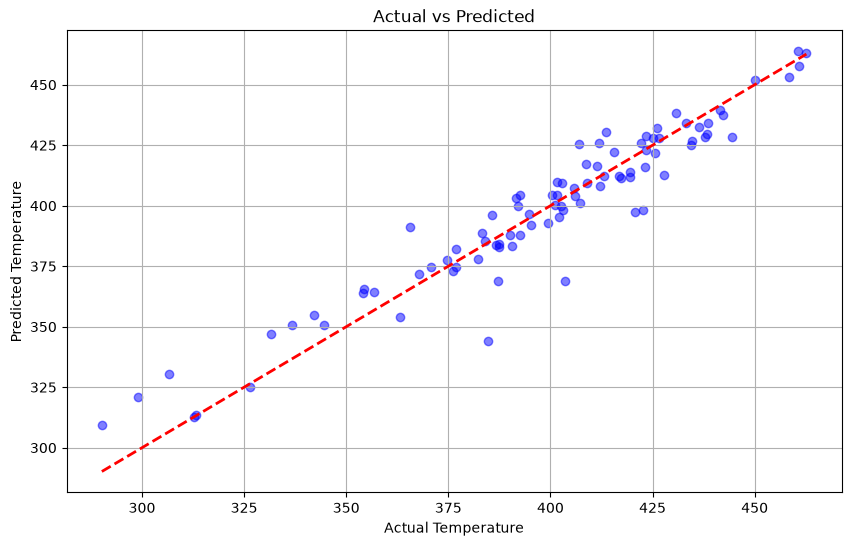

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

### 2. Actual vs Predicted (Hexbin Density)
**(Use: Density Proof)** Similar to the scatter plot, but colors show density. It proves where the vast majority of predictions land, rather than just showing outliers.

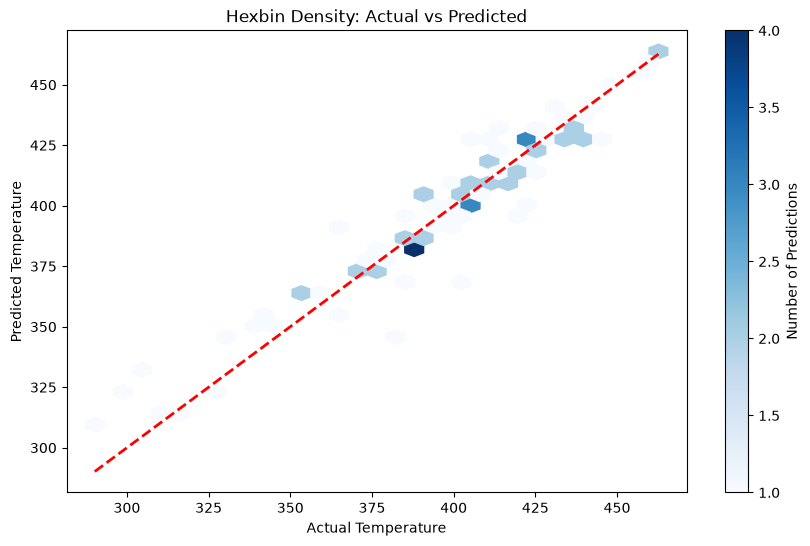

In [4]:
plt.figure(figsize=(10,6))
hb = plt.hexbin(y_test, y_pred, gridsize=30, cmap='Blues', mincnt=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.colorbar(hb, label='Number of Predictions')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Hexbin Density: Actual vs Predicted')
plt.show()

### 3. Residuals vs Predicted (Scatter)
**(Use: Consistency Check - Homoscedasticity)** This checks if the AI makes larger mistakes when temperatures get hotter. We want the blue dots to look like a random cloud, not a funnel.

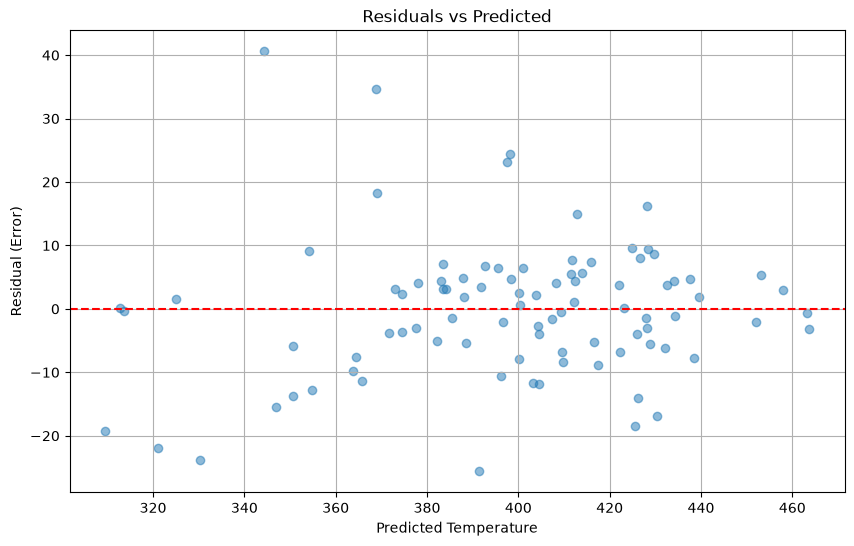

In [5]:
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Temperature')
plt.ylabel('Residual (Error)')
plt.title('Residuals vs Predicted')
plt.grid(True)
plt.show()

### 4. Residuals Distribution (Histogram)
**(Use: Bias Check)** This proves the mistakes the AI makes are completely random. We want a perfect bell curve centered at zero.

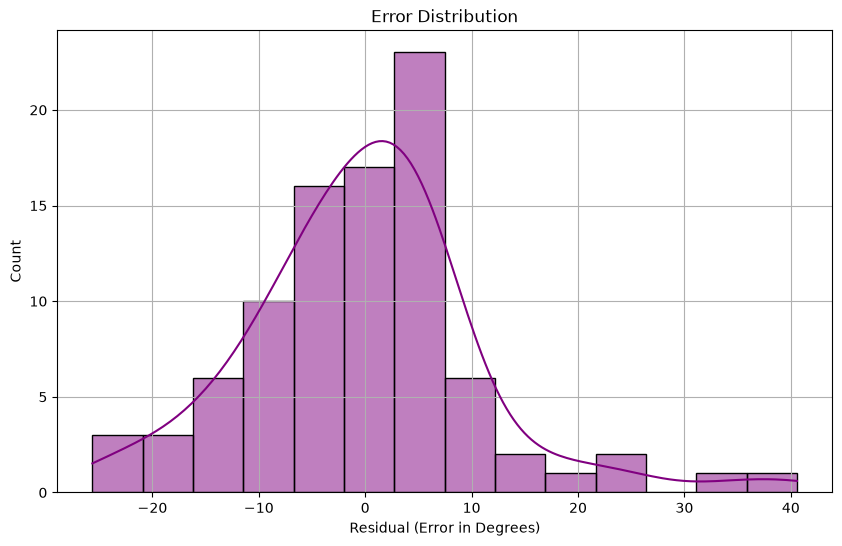

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residual (Error in Degrees)')
plt.title('Error Distribution')
plt.grid(True)
plt.show()

### 5. Q-Q Plot of Residuals
**(Use: Hardcore Statistics Proof)** Another visual proof of a perfect bell curve. If the blue dots stick to the red line, the AI's mistakes follow a perfect normal distribution without extreme biases.

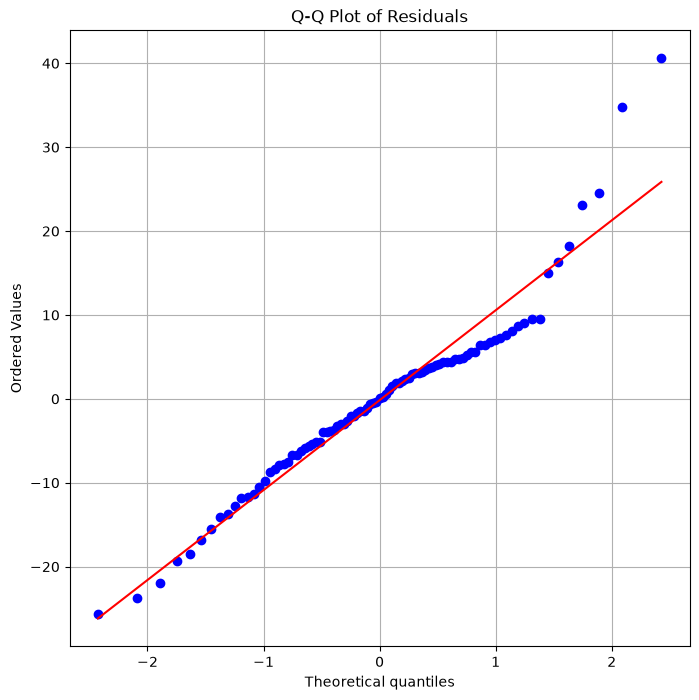

In [7]:
plt.figure(figsize=(8,8))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

### 6. Absolute Error Boxplot
**(Use: Error Sizing)** Shows the exact range of mistakes. The box contains 50% of all predictions. It shows you exactly how tight the AI's accuracy window is.

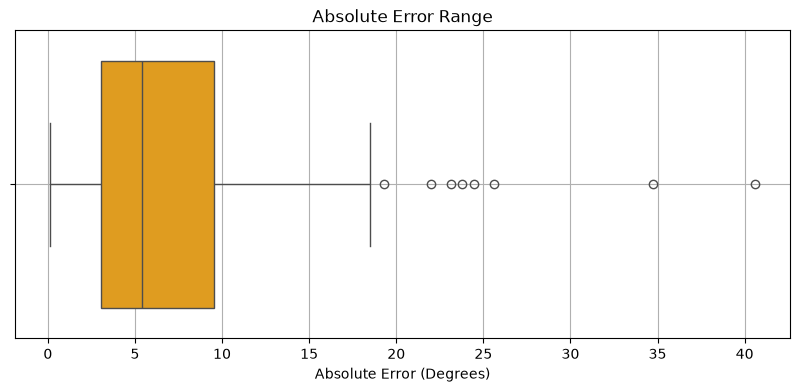

In [8]:
abs_error = np.abs(residuals)
plt.figure(figsize=(10,4))
sns.boxplot(x=abs_error, color='orange')
plt.xlabel('Absolute Error (Degrees)')
plt.title('Absolute Error Range')
plt.grid(True)
plt.show()

### 7. Feature Importance / Coefficients
**(Use: Maintenance Focus)** Shows exactly which sensors this specific AI pays the most attention to when calculating temperature. *(Note: Not all mathematical models support this graph).*

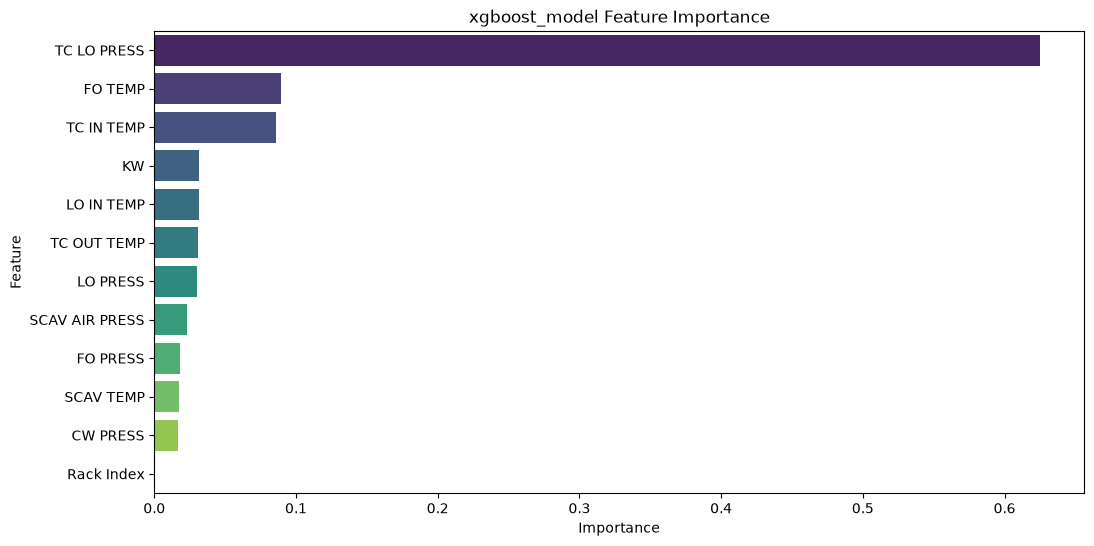

In [9]:
try:
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_)
    else:
        raise ValueError('No feature importances found for this model.')
    
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': imp}).sort_values('Importance', ascending=False)
    plt.figure(figsize=(12,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
    plt.title(f'{model_name} Feature Importance')
    plt.show()
except Exception as e:
    print(f'Cannot plot feature importance: {e}')